# 2 — Autoencoder (VAE): ricostruzione

Primo stadio: un **autoencoder** (`AutoencoderKlMaisi`) comprime i volumi `256^3` in latenti `4x64x64x64` (compressione 4x per asse) e li ricostruisce.

La qualita' di ricostruzione e' il **tetto** della qualita' di generazione: l'LDM lavora nel latente, quindi non puo' produrre dettagli che il decoder non ricostruisce.

**Metriche (test set)**: SSIM ~0.98, PSNR ~34.6 dB, L1 ~0.005.

In [1]:
import os, sys, json, glob
ROOT=os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

def show_ortho(vol, title=None, ax_row=None, cmap="gray"):
    """Mostra le 3 viste ortogonali (centrali) di un volume 3D."""
    if hasattr(vol, "numpy"):
        vol=vol.numpy()
    vol=np.asarray(vol).squeeze()
    x, y, z=[s // 2 for s in vol.shape]
    views=[(np.rot90(vol[x, :, :]), "Sagittale"),
             (np.rot90(vol[:, y, :]), "Coronale"),
             (np.rot90(vol[:, :, z]), "Assiale")]
    axes=ax_row if ax_row is not None else plt.subplots(1, 3, figsize=(12, 4))[1]
    for a, (img, name) in zip(axes, views):
        a.imshow(img, cmap=cmap); a.set_title(name); a.axis("off")
    if title and ax_row is None:
        plt.suptitle(title); plt.tight_layout()
    return axes


## Esempi di ricostruzione
Confronto reale vs ricostruzione (immagini gia' prodotte).

4 immagini di ricostruzione trovate


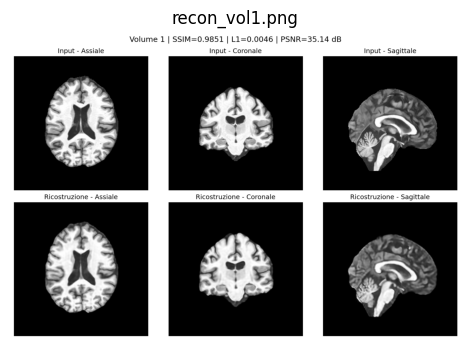

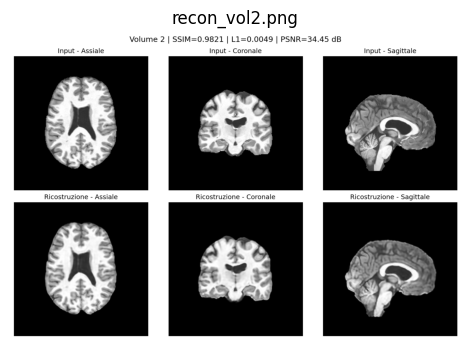

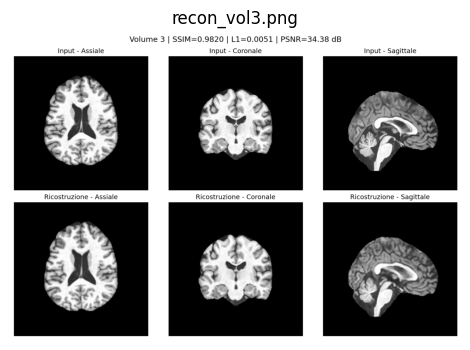

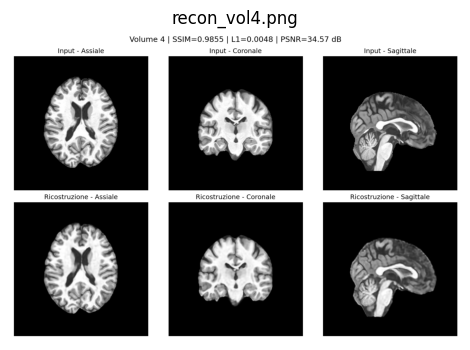

In [2]:
recon_pngs=sorted(glob.glob("outputs/generated/reconstructions/recon_vol*.png"))
print(f"{len(recon_pngs)} immagini di ricostruzione trovate")
for p in recon_pngs:
    fig, ax=plt.subplots(figsize=(12, 4))
    ax.imshow(mpimg.imread(p)); ax.axis("off"); ax.set_title(os.path.basename(p))
    plt.show()

## Curve di training del VAE

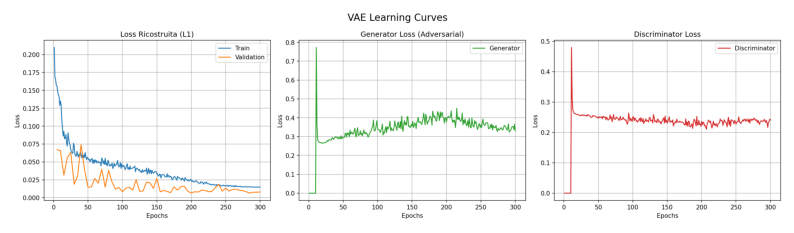

In [3]:
lc = "outputs/metrics/learning_curves_vae.png"
if os.path.exists(lc):
    fig, ax=plt.subplots(figsize=(10, 6))
    ax.imshow(mpimg.imread(lc)); ax.axis("off"); plt.show()
else:
    print("learning_curves_vae.png non trovato")

**Osservazione.** Le ricostruzioni preservano le strutture anatomiche principali con un leggero *smoothing* (coerente con PSNR ~34.6 dB). Fedelta' adeguata per addestrare l'LDM; il margine rispetto a VAE di riferimento (PSNR 37-39) indica nello stadio di compressione il principale collo di bottiglia per migliorare la nitidezza.